<a href="https://colab.research.google.com/github/achyut-balaji/Wildfire-Factors/blob/main/WIldfire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#Library Installation

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import graphviz
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import export_graphviz
from sklearn import tree

In [15]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [16]:
import pandas as pd
csv_path = '/content/drive/MyDrive/Wildfire/Real forestfires - forestfires.csv'
df = pd.read_csv(csv_path)
display(df.head())

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [17]:
# Convert 'month' to numerical values
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df['month'] = df['month'].map(month_mapping)

In [18]:
# Convert 'day' to numerical values
day_mapping = {
    'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6, 'sun': 7
}
df['day'] = df['day'].map(day_mapping)

In [19]:
# Display the DataFrame head to verify the changes
display(df.head())

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [20]:
#What I want to predict(Target) Input is what goes in.
inputs = df.drop(['X','Y','rain','temp','FFMC','DMC','DC','ISI','RH'],axis='columns')
target = df[['wind','month','day']]


In [21]:
inputs = np.array(inputs, dtype=float)
target = np.array(target, dtype=float)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=40)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (413, 4)
X_test shape: (104, 4)
y_train shape: (413, 3)
y_test shape: (104, 3)


In [23]:
model = RandomForestRegressor()

In [24]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [25]:
# Using the trained model to make predictions on the test data (X_test)
y_pred = model.predict(X_test)

# Rounding to 1 decimal place
rounded_y_pred = np.round(y_pred, 1)

# Printing the predicted labels
print(rounded_y_pred)

[[ 4.   8.   7. ]
 [ 2.6  3.   1.2]
 [ 4.   9.   4. ]
 [ 2.1  9.   6. ]
 [ 7.4  7.3  3.1]
 [ 1.4  2.4  6.2]
 [ 4.8  6.6  5.1]
 [ 3.9  8.   1.9]
 [ 6.3  9.2  1.5]
 [ 5.5  8.   7. ]
 [ 5.8  2.9  1.1]
 [ 5.4  8.   2. ]
 [ 4.7  6.8  3.7]
 [ 3.6  9.   5. ]
 [ 3.6  9.   5. ]
 [ 2.2  8.   7. ]
 [ 3.8  8.   6. ]
 [ 2.6  6.6  6.1]
 [ 5.6  3.   5.9]
 [ 5.1  9.   6.9]
 [ 3.   9.   1. ]
 [ 5.2  9.   6.9]
 [ 4.9  3.   6.3]
 [ 4.   9.1  6. ]
 [ 3.6  9.   7. ]
 [ 4.   8.   3. ]
 [ 2.7  9.   6. ]
 [ 5.6  9.   5. ]
 [ 5.5  8.   7. ]
 [ 3.5  8.   3. ]
 [ 3.6  9.   5. ]
 [ 3.2  3.   1. ]
 [ 2.   6.8  6.6]
 [ 4.5  8.   3. ]
 [ 2.1  9.   2. ]
 [ 7.4  8.1  6. ]
 [ 2.2  8.   1. ]
 [ 4.8  8.   2. ]
 [ 2.1  8.1  5.4]
 [ 4.7  9.   5. ]
 [ 5.7  3.   4. ]
 [ 3.2  8.   1. ]
 [ 8.7  2.6  5.2]
 [ 1.8  7.   6. ]
 [ 4.9  8.   6. ]
 [ 2.7  9.   6. ]
 [ 3.2  9.   7. ]
 [ 7.   8.3  5.2]
 [ 6.2  3.   5. ]
 [ 3.6  8.   4. ]
 [ 3.1  9.   6. ]
 [ 1.9  8.3  3.7]
 [ 4.8  9.   1.9]
 [ 4.8  8.   3.8]
 [ 4.7  8.   3.8]
 [ 1.   8.

In [26]:
print(y_test)

[[ 4.   8.   7. ]
 [ 1.8  3.   1. ]
 [ 4.   9.   4. ]
 [ 2.2  9.   6. ]
 [ 7.2  7.   3. ]
 [ 0.9  1.   7. ]
 [ 5.4  6.   5. ]
 [ 4.   8.   2. ]
 [ 6.3  9.   1. ]
 [ 5.4  8.   7. ]
 [ 5.8  3.   1. ]
 [ 5.4  8.   2. ]
 [ 4.5  7.   4. ]
 [ 3.6  9.   5. ]
 [ 3.6  9.   5. ]
 [ 2.2  8.   7. ]
 [ 3.6  8.   6. ]
 [ 2.7  6.   6. ]
 [ 5.4  3.   6. ]
 [ 4.9  9.   7. ]
 [ 3.1  9.   1. ]
 [ 5.4  9.   7. ]
 [ 4.9  3.   7. ]
 [ 4.   9.   6. ]
 [ 3.6  9.   7. ]
 [ 4.   8.   3. ]
 [ 2.7  9.   6. ]
 [ 5.8  9.   5. ]
 [ 5.4  8.   7. ]
 [ 3.6  8.   3. ]
 [ 3.6  9.   5. ]
 [ 4.   3.   1. ]
 [ 2.2  7.   7. ]
 [ 4.5  8.   3. ]
 [ 2.2  9.   2. ]
 [ 8.   8.   6. ]
 [ 2.2  8.   1. ]
 [ 4.9  8.   2. ]
 [ 2.2  8.   5. ]
 [ 4.5  9.   5. ]
 [ 5.4  3.   4. ]
 [ 3.1  8.   1. ]
 [ 8.   2.   5. ]
 [ 1.8  7.   6. ]
 [ 4.9  8.   6. ]
 [ 2.7  9.   6. ]
 [ 3.1  9.   7. ]
 [ 6.7  8.   5. ]
 [ 6.7  3.   5. ]
 [ 3.6  8.   4. ]
 [ 3.1  9.   6. ]
 [ 1.8  8.   4. ]
 [ 4.9  9.   2. ]
 [ 4.9  8.   4. ]
 [ 4.9  8.   4. ]
 [ 0.9  8.

In [27]:
# Calculate Mean Absolute Error
mae = np.mean(np.abs(y_test - y_pred))
mae_wind = np.mean(np.abs(y_test[0] - y_pred[0]))
mae_month = np.mean(np.abs(y_test[1] - y_pred[1]))
mae_day = np.mean(np.abs(y_test[2] - y_pred[2]))

print("Overall Mean Absolute Error:", mae)
print("Wind: Mean Absolute Error", mae_wind)
print("Rain: Mean Absolute Error:", mae_month)
print("Temp: Mean Absolute Error:", mae_day)

Overall Mean Absolute Error: 0.1208910256410257
Wind: Mean Absolute Error 0.024999999999999762
Rain: Mean Absolute Error: 0.322333333333332
Temp: Mean Absolute Error: 0.03233333333333347


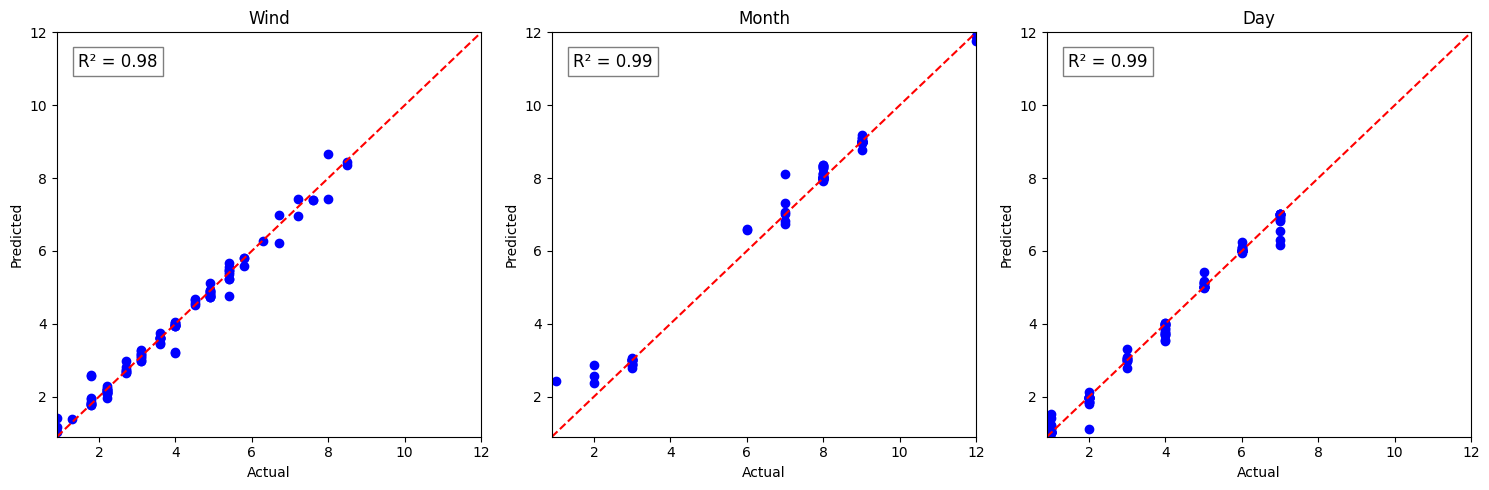

In [28]:
# Number of features
n_features = y_test.shape[1]

# Create subplots
fig, axes = plt.subplots(1, n_features, figsize=(15, 5))

# Titles for each subplot
titles = ['Wind', 'Month', 'Day']

# Determine common axis limits
x_min = min(y_test.min(), y_pred.min())
x_max = max(y_test.max(), y_pred.max())

for i in range(n_features):
    axes[i].scatter(y_test[:, i], y_pred[:, i], c='blue')
    axes[i].plot([x_min, x_max], [x_min, x_max], 'r--')
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(x_min, x_max)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(titles[i])

    # Calculate and annotate R² value
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    axes[i].text(0.05, 0.95, f'R² = {r2:.2f}', transform=axes[i].transAxes,
                 verticalalignment='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
import random

# Generate random values for the model inputs
month_model_input = float(random.randint(1, 12))
day_model_input = float(random.randint(1, 7))
wind_model_input = float(random.uniform(0.0, 10.0))  # Assuming wind usually ranges from 0 to 10
area_model_input = float(random.uniform(0.0, 20.0))  # Assuming area can range from 0 to 20

# Create a numpy array for the model prediction
model_input_features = np.array([[month_model_input, day_model_input, wind_model_input, area_model_input]])

# Make ONE prediction using the trained model
raw_prediction = model.predict(model_input_features)
rounded_prediction = np.round(raw_prediction, 1)

# Extract the true predicted values from the model
true_predicted_wind = rounded_prediction[0, 0]
true_predicted_month = rounded_prediction[0, 1]
true_predicted_day = rounded_prediction[0, 2]

print("Model has made its prediction based on randomly generated inputs. Now, let's play 'High or Low' for each of the predicted values!\n")

# --- Game for Wind ---
print("--- Guess the Predicted Wind ---")
guess_correct_wind = False
wind_attempts = 0
while not guess_correct_wind:
    wind_attempts += 1
    try:
        user_guess_wind = float(input("Your guess for Wind: "))
    except ValueError:
        print("Invalid input. Please enter a number.")
        continue

    if abs(user_guess_wind - true_predicted_wind) < 0.2: # Tolerance for 'SPOT ON'
        if wind_attempts == 1:
            print(f"🎉 Good job! You got it on your first try! Your guess {user_guess_wind} was very close.")
        else:
            print(f"🎉 SPOT ON! Your guess {user_guess_wind} was very close.")
        guess_correct_wind = True
    elif user_guess_wind > true_predicted_wind:
        print(f"⬇️ Too HIGH! Your guess {user_guess_wind} was higher. Try again!")
    else:
        print(f"⬆️ Too LOW! Your guess {user_guess_wind} was lower. Try again!")
print("---------------------------------\n")

# --- Game for Month ---
print("--- Guess the Predicted Month ---")
guess_correct_month = False
month_attempts = 0
while not guess_correct_month:
    month_attempts += 1
    try:
        user_guess_month = float(input("Your guess for Month: "))
    except ValueError:
        print("Invalid input. Please enter a number.")
        continue

    if abs(user_guess_month - true_predicted_month) < 0.5: # Tolerance for 'SPOT ON'
        if month_attempts == 1:
            print(f"🎉 Good job! You got it on your first try! Your guess {user_guess_month} was very close.")
        else:
            print(f"🎉 SPOT ON! Your guess {user_guess_month} was very close.")
        guess_correct_month = True
    elif user_guess_month > true_predicted_month:
        print(f"⬇️ Too HIGH! Your guess {user_guess_month} was higher. Try again!")
    else:
        print(f"⬆️ Too LOW! Your guess {user_guess_month} was lower. Try again!")
print("-----------------------------------\n")

# --- Game for Day ---
print("--- Guess the Predicted Day ---")
guess_correct_day = False
day_attempts = 0
while not guess_correct_day:
    day_attempts += 1
    try:
        user_guess_day = float(input("Your guess for Day: "))
    except ValueError:
        print("Invalid input. Please enter a number.")
        continue

    if abs(user_guess_day - true_predicted_day) < 0.2: # Tolerance for 'SPOT ON'
        if day_attempts == 1:
            print(f"🎉 Good job! You got it on your first try! Your guess {user_guess_day} was very close.")
        else:
            print(f"🎉 SPOT ON! Your guess {user_guess_day} was very close.")
        guess_correct_day = True
    elif user_guess_day > true_predicted_day:
        print(f"⬇️ Too HIGH! Your guess {user_guess_day} was higher. Try again!")
    else:
        print(f"⬆️ Too LOW! Your guess {user_guess_day} was lower. Try again!")
print("---------------------------------\n")

Model has made its prediction based on randomly generated inputs. Now, let's play 'High or Low' for each of the predicted values!

--- Guess the Predicted Wind ---
Your guess for Wind: 2
⬆️ Too LOW! Your guess 2.0 was lower. Try again!
Your guess for Wind: 3
⬆️ Too LOW! Your guess 3.0 was lower. Try again!
Your guess for Wind: 4
⬆️ Too LOW! Your guess 4.0 was lower. Try again!
Your guess for Wind: 5
⬆️ Too LOW! Your guess 5.0 was lower. Try again!
Your guess for Wind: 6
⬇️ Too HIGH! Your guess 6.0 was higher. Try again!
Your guess for Wind: 7
⬇️ Too HIGH! Your guess 7.0 was higher. Try again!
Your guess for Wind: 5.5
⬆️ Too LOW! Your guess 5.5 was lower. Try again!
Your guess for Wind: 5.7
🎉 SPOT ON! Your guess 5.7 was very close.
---------------------------------

--- Guess the Predicted Month ---
Your guess for Month: 3
🎉 Good job! You got it on your first try! Your guess 3.0 was very close.
-----------------------------------

--- Guess the Predicted Day ---
Your guess for Day: 23
⬇

In [1]:
import random
import time

# --- Forest States ---
empty = ' '
tree = '🌲'
fire = '🔥'
burned = '.'

# --- Simulation Parameters ---
GRID_WIDTH = 60
GRID_HEIGHT = 40
INITIAL_TREE_DENSITY = 2
INITIAL_FIRE_COUNT = 5

# --- Grid Initialization ---
def create_initial_grid(tree_density, initial_fire_count):
    grid = [[empty for i in range(GRID_WIDTH)] for i in range(GRID_HEIGHT)]
    for r in range(GRID_HEIGHT):
        for c in range(GRID_WIDTH):
            if random.random() < tree_density:
                grid[r][c] = tree

    # Place initial fires
    for _ in range(initial_fire_count):
        r, c = random.randint(0, GRID_HEIGHT - 1), random.randint(0, GRID_WIDTH - 1)
        if grid[r][c] == tree:
            grid[r][c] = fire
    return grid

def print_grid(grid):
    print('+' + '-' * GRID_WIDTH + '+')
    for row in grid:
        print('|' + ''.join(row) + '|')
    print('+' + '-' * GRID_WIDTH + '+')

def spread_fire(grid):
    new_grid = [row[:] for row in grid] # Create a copy
    fire_spread_happened = False
    for r in range(GRID_HEIGHT):
        for c in range(GRID_WIDTH):
            if grid[r][c] == fire:
                new_grid[r][c] = burned # Fire burns out
                # Check neighbors
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:
                        # Ensure not checking the cell itself and within grid bounds
                        if (dr != 0 or dc != 0) and (0 <= r + dr < GRID_HEIGHT) and (0 <= c + dc < GRID_WIDTH):
                            if grid[r + dr][c + dc] == tree:
                                new_grid[r + dr][c + dc] = fire # Spread to tree
                                fire_spread_happened = True
    return new_grid, fire_spread_happened

# --- Main Simulation ---
def run_simulation():
    grid = create_initial_grid(INITIAL_TREE_DENSITY, INITIAL_FIRE_COUNT)

    print("\nStarting text-based forest fire simulation!\n")
    print("Key: T = Tree, F = Fire, . = Burned,   = Empty Space")
    print_grid(grid)
    time.sleep(1) # Initial pause

    step = 0
    while True:
        step += 1
        new_grid, fire_spread_happened = spread_fire(grid)
        grid = new_grid

        print(f"\n--- Step {step} ---")
        print_grid(grid)

        if not fire_spread_happened: # If no fire spread in this step, simulation ends
            print(f"Forest fire simulation ended after {step} steps. No more fire can spread.\n")
            break

        time.sleep(0.6) # Control simulation speed

# Run the simulation
run_simulation()

print("---------------------------------\n")
print("Congratulations! You've guessed all the predicted values from the model!")


Starting text-based forest fire simulation!

Key: T = Tree, F = Fire, . = Burned,   = Empty Space
+------------------------------------------------------------+
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🔥🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🔥🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🔥🌲🌲🌲🌲🌲🌲🌲🌲🌲|
|🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲🌲

In [29]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test data
dt_y_pred = dt_model.predict(X_test)

# Rounding to 1 decimal place
rounded_dt_y_pred = np.round(dt_y_pred, 1)

print("\n--- Decision Tree Regressor Predictions ---")
print(rounded_dt_y_pred)

# Calculate Mean Absolute Error for Decision Tree Regressor
dt_mae = np.mean(np.abs(y_test - dt_y_pred))
dt_mae_wind = np.mean(np.abs(y_test[:, 0] - dt_y_pred[:, 0]))
dt_mae_month = np.mean(np.abs(y_test[:, 1] - dt_y_pred[:, 1]))
dt_mae_day = np.mean(np.abs(y_test[:, 2] - dt_y_pred[:, 2]))

print("--- Decision Tree Regressor Evaluation ---")
print("Overall Mean Absolute Error (Decision Tree):", dt_mae)
print("Wind MAE (Decision Tree):", dt_mae_wind)
print("Month MAE (Decision Tree):", dt_mae_month)
print("Day MAE (Decision Tree):", dt_mae_day)

# Calculate R-squared for Decision Tree Regressor
dt_r2_wind = r2_score(y_test[:, 0], dt_y_pred[:, 0])
dt_r2_month = r2_score(y_test[:, 1], dt_y_pred[:, 1])
dt_r2_day = r2_score(y_test[:, 2], dt_y_pred[:, 2])

print("Wind R-squared (Decision Tree):", dt_r2_wind)
print("Month R-squared (Decision Tree):", dt_r2_month)
print("Day R-squared (Decision Tree):", dt_r2_day)



--- Decision Tree Regressor Predictions ---
[[ 4.   8.   7. ]
 [ 2.2  3.   1. ]
 [ 4.   9.   4. ]
 [ 2.2  9.   6. ]
 [ 9.4  6.   4. ]
 [ 1.8  4.   7. ]
 [ 4.5  6.   5. ]
 [ 4.   8.   2. ]
 [ 5.4  9.   1. ]
 [ 5.8  8.   7. ]
 [ 5.8  3.   1. ]
 [ 5.4  8.   2. ]
 [ 4.9  7.   4. ]
 [ 3.6  9.   5. ]
 [ 3.6  9.   5. ]
 [ 2.2  8.   7. ]
 [ 3.6  8.   6. ]
 [ 3.1  6.   6. ]
 [ 5.4  3.   6. ]
 [ 4.9  9.   7. ]
 [ 2.7  9.   1. ]
 [ 5.4  9.   7. ]
 [ 4.9  3.   6. ]
 [ 4.   9.   6. ]
 [ 3.6  9.   7. ]
 [ 4.   8.   3. ]
 [ 2.7  9.   6. ]
 [ 5.8  9.   5. ]
 [ 5.8  8.   7. ]
 [ 3.6  8.   3. ]
 [ 3.6  9.   5. ]
 [ 3.1  3.   1. ]
 [ 1.8  7.   6. ]
 [ 4.5  8.   3. ]
 [ 0.9 10.   2. ]
 [ 7.6  8.   5. ]
 [ 2.2  8.   1. ]
 [ 4.9  8.   2. ]
 [ 2.2  8.   6. ]
 [ 4.5  9.   5. ]
 [ 5.8  3.   4. ]
 [ 3.1  8.   1. ]
 [ 7.6  3.   5. ]
 [ 1.8  7.   6. ]
 [ 4.9  8.   6. ]
 [ 2.7  9.   6. ]
 [ 3.1  9.   7. ]
 [ 6.3  9.   5. ]
 [ 6.3  3.   5. ]
 [ 3.6  8.   4. ]
 [ 3.1  9.   6. ]
 [ 2.2  8.   3. ]
 [ 4.5  9.   2. ]
 